# Probability and probability distributions

This notebook begins Course 3 of the Mathematics for Machine Learning and Data Science Specialization. The course develops probability and statistics as tools for interpreting uncertainty, fitting machine-learning models, and drawing careful conclusions from data.

## Welcome to Course 3

Probability and statistics provide a framework for answering questions such as:

- How uncertain is a model's prediction?
- How should a probability output be used in a downstream decision?
- Which model most plausibly explains the observed data?
- When is a loss function appropriate for the assumptions about the data?
- Does an observed experimental difference provide convincing evidence of a real effect?

This framework helps explain why learning algorithms use particular objectives and how those choices might be adapted when their assumptions do not fit the problem.

## Video 1 — Why probability and statistics matter for machine learning

Many machine-learning outputs can be interpreted probabilistically. A spam classifier, for example, may estimate

$$
P(\text{spam}\mid\text{observed words and features}).
$$

Here:

- $P$ denotes probability;
- the vertical bar $\mid$ means “given”;
- the words and other email features are the available evidence.

The numerical probability is not the final decision by itself. A system must still decide what to do with it—for example, whether to move the email to a spam folder or show it to the user. That decision can depend on the costs of false positives and false negatives.

### Bayes' theorem and conditional probability

**Conditional probability** measures the probability of an event after accounting for known information. Bayes' theorem provides a rule for updating a probability when new evidence is observed.

The course previews two examples:

1. estimating the probability that an email is spam given its words and features;
2. estimating the probability of a rare illness after receiving a positive test result.

A positive test does not by itself determine the probability of having the illness. The conclusion also depends on factors such as:

- how common the illness is before testing;
- how often the test detects the illness when it is present;
- how often the test reports a positive result when the illness is absent.

For a rare illness, false positives among the much larger healthy population can sometimes outnumber true positives. Bayes' theorem combines all of this information.

### Maximum likelihood estimation

**Maximum likelihood estimation** chooses model parameters that make the observed data as probable as possible under the model.

The central question is:

> Which model most likely generated the data that were observed?

This viewpoint appears throughout machine learning. Instead of treating a training objective as an arbitrary formula, probability can explain why that objective is appropriate for a particular model of the data.

### Why Gaussian assumptions lead to squared error

The course previews a connection among three ideas:

1. observations are modeled using a Gaussian distribution;
2. model parameters are chosen by maximum likelihood;
3. the resulting optimization objective involves squared errors.

More precisely, when independent prediction errors are assumed to be Gaussian with a fixed variance, minimizing the negative log-likelihood is equivalent—up to constants and a positive scaling factor—to minimizing a sum of squared errors.

This helps explain when squared error is a sensible choice. If the data's error pattern is poorly described by a Gaussian model, another likelihood and another loss function may be more appropriate.

### A probabilistic view of regularization

Probability can also help explain regularization. In a Bayesian model, parameters themselves are assigned a probability distribution called a **prior**.

A Gaussian prior centered at zero prefers smaller parameter values. Combining that prior with the data likelihood and performing maximum a posteriori estimation produces a squared-parameter penalty—the familiar form of $L_2$ regularization.

This interpretation connects a modeling belief about plausible parameters with the optimization penalty used during training.

### Hypothesis testing and careful conclusions

**Hypothesis testing** provides a framework for evaluating claims using sampled data. Applications include:

- testing whether a drug produces a meaningful benefit;
- testing whether a webpage change increases engagement;
- deciding whether an observed difference is plausibly explained by random variation.

Terms such as **confidence interval**, **confidence level**, and **p-value** have precise mathematical meanings that can differ from their informal everyday interpretations. The course will develop those definitions so experimental and scientific conclusions can be reported accurately.

### Course concept map

| Topic | Main question | Machine-learning connection |
|---|---|---|
| Conditional probability | How does evidence change a probability? | Interpreting predictions given features |
| Bayes' theorem | How can a probability be updated using evidence? | Spam detection and diagnostic reasoning |
| Probability distributions | How are uncertain outcomes modeled? | Gaussian and other data models |
| Maximum likelihood | Which parameters make the data most probable? | Training probabilistic models |
| Negative log-likelihood | How can likelihood maximization become loss minimization? | Classification and regression objectives |
| Priors and regularization | Which parameter values were plausible before seeing the data? | $L_2$ regularization from a Gaussian prior |
| Hypothesis testing | Does the evidence support a claimed effect? | Experiments, A/B tests, and scientific conclusions |

### Takeaway

Probability and statistics are not only tools for calculating chances. They provide a language for:

- representing uncertainty;
- interpreting model outputs;
- deriving training objectives from assumptions;
- choosing and fitting models;
- evaluating evidence and communicating conclusions precisely.

The rest of the course develops the mathematical tools behind these connections, beginning with probability and probability distributions.

## Video 2 — Experiments, sample spaces, events, and probability

Week 1 has two lessons:

1. rules of probability and Bayes' theorem;
2. probability distributions and commonly used examples.

A **probability** measures how likely an event is to occur. It is a number between $0$ and $1$:

- $0$ means the event is impossible;
- $1$ means the event is certain;
- values between $0$ and $1$ represent intermediate likelihoods.

For example, a fair coin has

$$
P(\text{heads})=\frac12=0.5,
$$

and a fair six-sided die has

$$
P(\text{rolling a 4})=\frac16.
$$

### Probability vocabulary

An **experiment** is a process that produces an uncertain outcome, such as selecting a child at random or tossing a coin.

An **outcome** is one possible result of the experiment.

The **sample space**, usually denoted by $S$, is the set of all possible outcomes.

An **event**, such as $A$, is the collection of outcomes of interest. In set notation,

$$
A\subseteq S.
$$

The notation $P(A)$ means “the probability that event $A$ occurs.”

### Counting equally likely outcomes

For a finite sample space in which every outcome is equally likely,

$$
\boxed{
P(A)
=
\frac{\text{number of outcomes in event }A}
{\text{total number of outcomes in sample space }S}
=
\frac{|A|}{|S|}.
}
$$

The equally likely assumption matters. The counting formula cannot be applied directly when some outcomes are more likely than others.

### School example

A school has $10$ children:

- $3$ play soccer;
- $7$ do not play soccer.

One child is selected uniformly at random, meaning every child has the same chance of being selected.

Let $A$ be the event “the selected child plays soccer.” Then

$$
|A|=3
\qquad\text{and}\qquad
|S|=10.
$$

Therefore,

$$
\boxed{
P(\text{soccer})
=
\frac3{10}
=0.3
=30\%.
}
$$

### Event inside the sample space

The rectangle below represents the entire sample space of ten children. The circle represents the soccer event containing three children. The seven other children remain inside the sample space but outside the event.

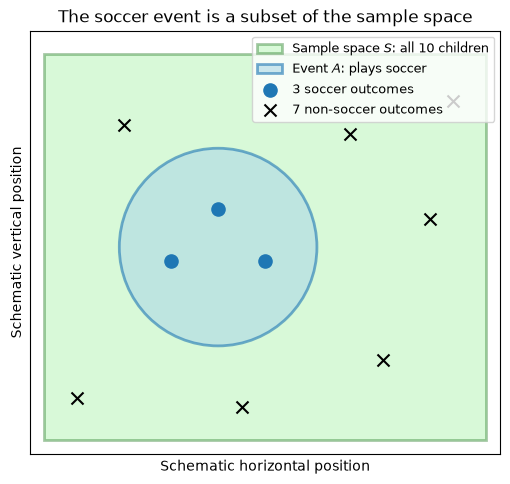

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle, Rectangle

soccer_positions: np.ndarray = np.array([[3.0, 4.1], [4.0, 5.2], [5.0, 4.1]])
non_soccer_positions: np.ndarray = np.array(
    [[1.0, 1.2], [2.0, 7.0], [6.8, 6.8], [8.5, 5.0], [7.5, 2.0], [4.5, 1.0], [9.0, 7.5]]
)

fig, ax = plt.subplots(figsize=(8.5, 5.5))
sample_space_rectangle = Rectangle((0.3, 0.3), 9.4, 8.2, facecolor="lightgreen",
                                   edgecolor="darkgreen", alpha=0.35, linewidth=2,
                                   label="Sample space $S$: all 10 children")
soccer_event_circle = Circle((4.0, 4.4), 2.1, facecolor="lightblue", edgecolor="tab:blue",
                             alpha=0.6, linewidth=2, label="Event $A$: plays soccer")
ax.add_patch(sample_space_rectangle)
ax.add_patch(soccer_event_circle)
ax.scatter(soccer_positions[:, 0], soccer_positions[:, 1], color="tab:blue", marker="o",
           s=90, label="3 soccer outcomes", zorder=3)
ax.scatter(non_soccer_positions[:, 0], non_soccer_positions[:, 1], color="black", marker="x",
           s=75, label="7 non-soccer outcomes", zorder=3)
ax.set(
    title="The soccer event is a subset of the sample space",
    xlabel="Schematic horizontal position",
    ylabel="Schematic vertical position",
    xlim=(0, 10),
    ylim=(0, 9),
)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
ax.legend(fontsize=9, loc="upper right")
plt.show()

### One fair coin

Tossing a coin is an experiment. For one fair coin, the sample space is

$$
S=\{H,T\},
$$

where $H$ means heads and $T$ means tails. Both outcomes are equally likely.

The event “heads” contains one of the two outcomes, so

$$
P(H)=\frac{|\{H\}|}{|\{H,T\}|}=\frac12=0.5.
$$

### Two fair coins

For two coin tosses, each first-toss outcome can be followed by either outcome on the second toss:

$$
S=\{HH,HT,TH,TT\}.
$$

These are ordered outcomes: $HT$ and $TH$ describe different sequences.

The event “both coins land heads” contains only $HH$. Therefore,

$$
\boxed{P(HH)=\frac14=0.25=25\%.}
$$

### Three fair coins

Three tosses produce eight equally likely ordered outcomes:

$$
S=
\{HHH,HHT,HTH,HTT,THH,THT,TTH,TTT\}.
$$

Only one outcome has three heads, so

$$
\boxed{P(HHH)=\frac18=0.125=12.5\%.}
$$

Each additional fair coin doubles the number of possible ordered outcomes. For $n$ fair independent tosses,

$$
|S|=2^n
$$

and the all-heads sequence is one outcome, giving

$$
P(\text{all heads in $n$ tosses})=\frac1{2^n}.
$$

### Takeaway

To calculate a basic probability by counting:

1. define the experiment;
2. list or count the sample-space outcomes;
3. identify the event outcomes;
4. verify that the outcomes are equally likely;
5. divide the event count by the sample-space count.

The examples give

| Experiment and event | Probability |
|---|---:|
| One fair coin: heads | $\frac12$ |
| Two fair coins: both heads | $\frac14$ |
| Three fair coins: all heads | $\frac18$ |
| Uniformly select one of ten children: plays soccer | $\frac3{10}$ |

This experiment–sample space–event framework supports the more advanced probability rules that follow.

## Video 3 — Probabilities from rolling fair dice

A fair six-sided die has the sample space

$$
S=\{1,2,3,4,5,6\}.
$$

All six outcomes are equally likely. For the event

$$
A=\{6\},
$$

there is one favorable outcome among six possible outcomes. Therefore,

$$
\boxed{P(6)=\frac16\approx0.1667.}
$$

### Rolling two dice

When two fair dice are rolled independently, an outcome is an ordered pair

$$
(i,j),
$$

where $i$ is the first die and $j$ is the second die. Each die has six possibilities, so the sample-space size is

$$
6\times6=36.
$$

The event “both dice show six” contains only the ordered pair $(6,6)$. Thus,

$$
\boxed{P(6,6)=\frac1{36}\approx0.0278.}
$$

The same result follows by multiplying the independent probabilities:

$$
P(6,6)=P(6\text{ on die 1})P(6\text{ on die 2})
=\frac16\cdot\frac16
=\frac1{36}.
$$

### The complete two-dice sample space

The $36$ ordered pairs range from $(1,1)$ through $(6,6)$. Pairs such as $(1,2)$ and $(2,1)$ are different because they assign different values to the first and second dice.

Only one cell in this $6\times6$ grid belongs to the event “both dice show six.”

### Empirical frequency and theoretical probability

The **empirical frequency** of an event is

$$
\frac{\text{number of times the event has occurred}}
{\text{number of experiments performed}}.
$$

A short sequence of rolls can produce a frequency far from the theoretical probability. As the number of independent rolls becomes large, the running frequency tends to settle near the theoretical value.

The following deterministic simulation uses a fixed random seed and synthetic die rolls. Its exact path is one possible experiment, not a guarantee about every finite sequence.

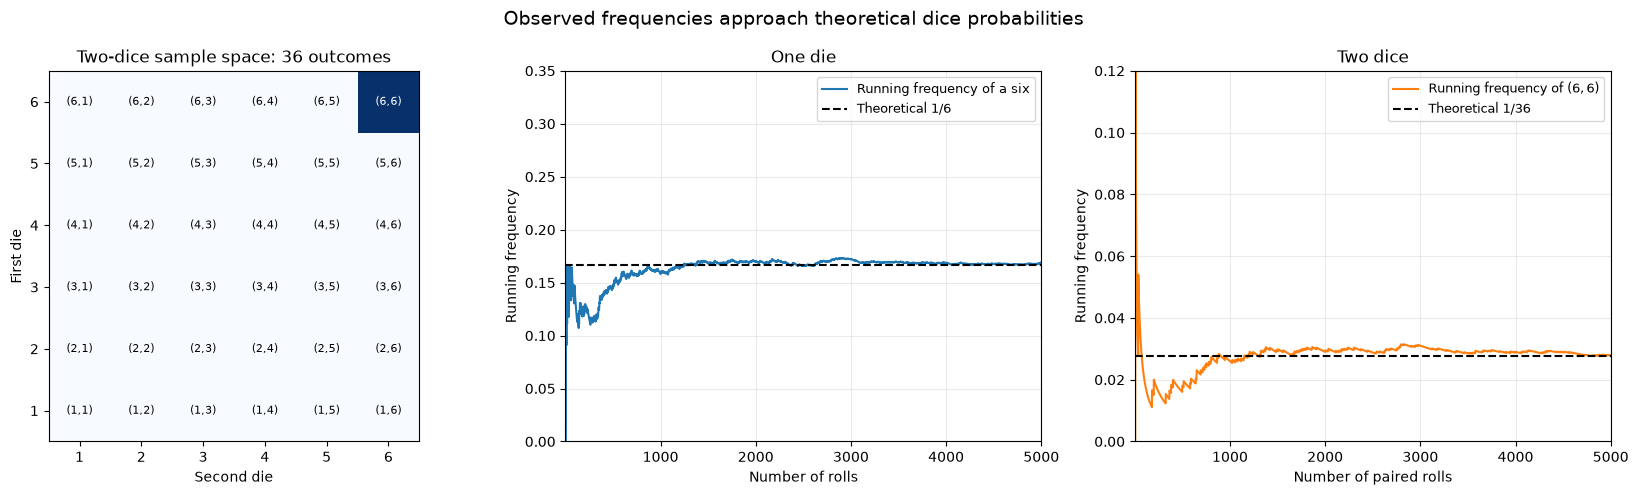

In [2]:
dice_rng: np.random.Generator = np.random.default_rng(42)
dice_simulation_count: int = 5_000
first_die_rolls: np.ndarray = dice_rng.integers(1, 7, size=dice_simulation_count)
second_die_rolls: np.ndarray = dice_rng.integers(1, 7, size=dice_simulation_count)
roll_numbers: np.ndarray = np.arange(1, dice_simulation_count + 1)
running_frequency_one_six: np.ndarray = np.cumsum(first_die_rolls == 6) / roll_numbers
running_frequency_double_six: np.ndarray = np.cumsum(
    (first_die_rolls == 6) & (second_die_rolls == 6)
) / roll_numbers

outcome_grid: np.ndarray = np.zeros((6, 6))
outcome_grid[5, 5] = 1.0

fig, axes = plt.subplots(1, 3, figsize=(17, 5.0))
axes[0].imshow(outcome_grid, cmap="Blues", origin="lower", vmin=0, vmax=1)
for first_value in range(1, 7):
    for second_value in range(1, 7):
        text_color: str = "white" if (first_value, second_value) == (6, 6) else "black"
        axes[0].text(second_value - 1, first_value - 1,
                     f"({first_value},{second_value})", ha="center", va="center",
                     color=text_color, fontsize=8)
axes[0].set(
    title="Two-dice sample space: 36 outcomes",
    xlabel="Second die",
    ylabel="First die",
    xticks=np.arange(6),
    yticks=np.arange(6),
    xticklabels=np.arange(1, 7),
    yticklabels=np.arange(1, 7),
)

axes[1].plot(roll_numbers, running_frequency_one_six, color="tab:blue", linewidth=1.5,
             label="Running frequency of a six")
axes[1].axhline(1 / 6, color="black", linestyle="--", label="Theoretical $1/6$")
axes[1].set(title="One die", xlabel="Number of rolls", ylabel="Running frequency",
            xlim=(1, dice_simulation_count), ylim=(0, 0.35))
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=9)

axes[2].plot(roll_numbers, running_frequency_double_six, color="tab:orange", linewidth=1.5,
             label="Running frequency of $(6,6)$")
axes[2].axhline(1 / 36, color="black", linestyle="--", label="Theoretical $1/36$")
axes[2].set(title="Two dice", xlabel="Number of paired rolls", ylabel="Running frequency",
            xlim=(1, dice_simulation_count), ylim=(0, 0.12))
axes[2].grid(alpha=0.25)
axes[2].legend(fontsize=9)

fig.suptitle("Observed frequencies approach theoretical dice probabilities", fontsize=14)
fig.tight_layout()
plt.show()

### Takeaway

For equally likely outcomes,

$$
P(A)=\frac{|A|}{|S|}.
$$

Applying this to fair dice:

| Experiment and event | Favorable outcomes | Sample-space size | Probability |
|---|---:|---:|---:|
| One die shows six | $1$ | $6$ | $\frac16$ |
| Two dice both show six | $1$ | $36$ | $\frac1{36}$ |

Theoretical probability describes the model for the experiment. Empirical frequency describes what has occurred in a particular set of rolls. With many independent repetitions, the empirical frequency generally stabilizes near the theoretical probability.

## Video 4 — The complement rule

The **complement** of an event $A$ is the event that $A$ does not occur. It can be written as $A^c$ or, as in the course, $A'$.

An event and its complement cover the entire sample space without overlapping:

$$
A\cup A^c=S
\qquad\text{and}\qquad
A\cap A^c=\varnothing.
$$

Therefore, their probabilities add to $1$:

$$
P(A)+P(A^c)=1.
$$

Rearranging gives the **complement rule**:

$$
\boxed{P(A^c)=1-P(A).}
$$

For example, if $P(A)=0.75$, then $P(A^c)=1-0.75=0.25$.

### School example

In the school of ten children:

- $3$ play soccer;
- $7$ do not play soccer.

Let $A$ be the event “the selected child plays soccer.” Then

$$
P(A)=\frac3{10}=0.3.
$$

Its complement $A^c$ is “the selected child does not play soccer.” Using the complement rule,

$$
\begin{aligned}
P(A^c)
&=1-P(A) \\
&=1-0.3 \\
&=0.7.
\end{aligned}
$$

This agrees with direct counting:

$$
P(\text{not soccer})=\frac7{10}=0.7.
$$

### The complement is everything outside the event

In a Venn-style diagram, the circle represents event $A$ and the part of the sample-space rectangle outside the circle represents $A^c$.

For three fair coin tosses, the event $A=\{HHH\}$ contains one outcome. Its complement contains all seven other outcomes.

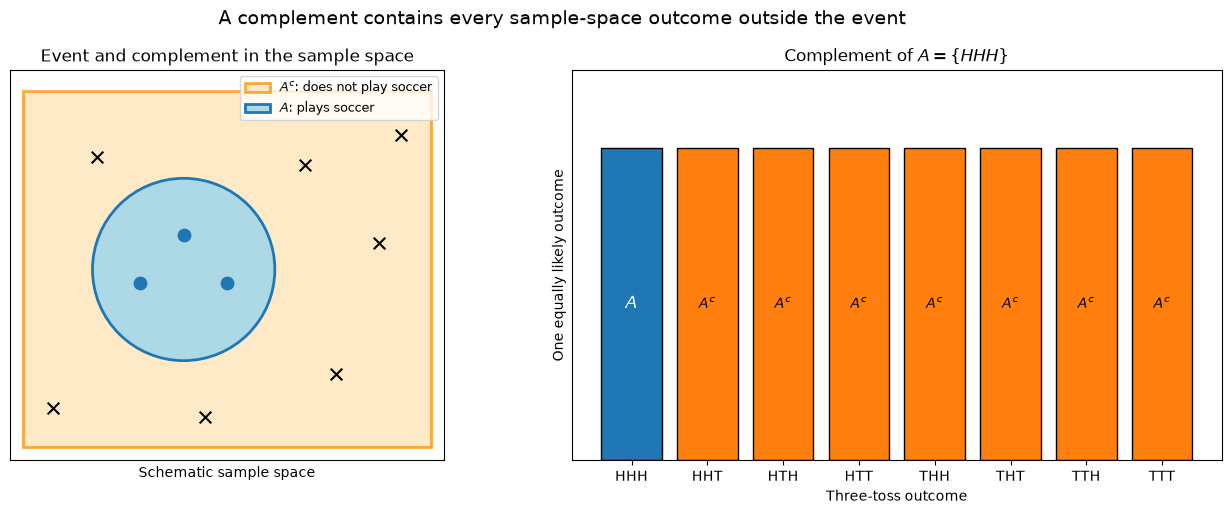

In [3]:
complement_soccer_positions: np.ndarray = np.array(
    [[3.0, 4.1], [4.0, 5.2], [5.0, 4.1]]
)
complement_non_soccer_positions: np.ndarray = np.array(
    [[1.0, 1.2], [2.0, 7.0], [6.8, 6.8], [8.5, 5.0], [7.5, 2.0], [4.5, 1.0], [9.0, 7.5]]
)
coin_three_outcomes: list[str] = ["HHH", "HHT", "HTH", "HTT", "THH", "THT", "TTH", "TTT"]
coin_complement_colors: list[str] = ["tab:blue"] + ["tab:orange"] * 7

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))
complement_rectangle = Rectangle((0.3, 0.3), 9.4, 8.2, facecolor="moccasin",
                                 edgecolor="darkorange", alpha=0.75, linewidth=2,
                                 label="$A^c$: does not play soccer")
complement_event_circle = Circle((4.0, 4.4), 2.1, facecolor="lightblue",
                                 edgecolor="tab:blue", alpha=1.0, linewidth=2,
                                 label="$A$: plays soccer")
axes[0].add_patch(complement_rectangle)
axes[0].add_patch(complement_event_circle)
axes[0].scatter(complement_soccer_positions[:, 0], complement_soccer_positions[:, 1],
                color="tab:blue", marker="o", s=80, zorder=3)
axes[0].scatter(complement_non_soccer_positions[:, 0], complement_non_soccer_positions[:, 1],
                color="black", marker="x", s=70, zorder=3)
axes[0].set(title="Event and complement in the sample space", xlim=(0, 10), ylim=(0, 9),
            xticks=[], yticks=[], xlabel="Schematic sample space", ylabel="")
axes[0].set_aspect("equal")
axes[0].legend(fontsize=9, loc="upper right")

axes[1].bar(coin_three_outcomes, np.ones(8), color=coin_complement_colors,
            edgecolor="black")
axes[1].set(title="Complement of $A=\\{HHH\\}$", xlabel="Three-toss outcome",
            ylabel="One equally likely outcome", ylim=(0, 1.25), yticks=[])
axes[1].text(0, 0.5, "$A$", ha="center", va="center", color="white", fontsize=12)
for outcome_index in range(1, 8):
    axes[1].text(outcome_index, 0.5, "$A^c$", ha="center", va="center", fontsize=10)
axes[1].grid(axis="y", alpha=0.2)

fig.suptitle("A complement contains every sample-space outcome outside the event", fontsize=14)
fig.tight_layout()
plt.show()

### Three coins: not all three are heads

For three fair coin tosses,

$$
P(HHH)=\frac18.
$$

The complement is the event “the outcome is not $HHH$,” so

$$
\begin{aligned}
P(\text{not all three heads})
&=1-P(HHH) \\
&=1-\frac18 \\
&=\boxed{\frac78}.
\end{aligned}
$$

> **Transcript clarification:** “not three heads” means **not all three tosses are heads**. It includes outcomes with zero, one, or two heads. It does not mean “no heads,” which would be only the outcome $TTT$.

### One die: anything except six

For a fair six-sided die,

$$
P(6)=\frac16.
$$

The complement contains the five outcomes $\{1,2,3,4,5\}$. Therefore,

$$
\begin{aligned}
P(\text{not }6)
&=1-P(6) \\
&=1-\frac16 \\
&=\frac66-\frac16 \\
&=\boxed{\frac56}.
\end{aligned}
$$

### Takeaway

The complement rule is

$$
\boxed{P(A^c)=1-P(A).}
$$

It is useful when the event itself is easier to calculate than all the ways in which it can fail.

| Event $A$ | $P(A)$ | Complement $A^c$ | $P(A^c)$ |
|---|---:|---|---:|
| Plays soccer | $\frac3{10}$ | Does not play soccer | $\frac7{10}$ |
| Three tosses are all heads | $\frac18$ | Not all three are heads | $\frac78$ |
| One die shows six | $\frac16$ | One die does not show six | $\frac56$ |

## Video 5 — Adding probabilities of disjoint events

The **union** of events $A$ and $B$, written $A\cup B$, is the event that $A$ occurs, $B$ occurs, or both occur.

Two events are **disjoint** when they cannot occur in the same experiment:

$$
A\cap B=\varnothing.
$$

Because disjoint events share no outcomes, their probabilities can be added without double-counting:

$$
\boxed{P(A\cup B)=P(A)+P(B)\qquad\text{when }A\cap B=\varnothing.}
$$

### School example

Suppose each child in a school can play at most one sport. Let

- $A$ be “the selected child plays soccer,” with $P(A)=0.3$;
- $B$ be “the selected child plays basketball,” with $P(B)=0.4$.

The one-sport rule makes the events disjoint: no child belongs to both events.

For a school of ten children, the event counts are $3$ and $4$. Therefore,

$$
\begin{aligned}
P(A\cup B)
&=P(A)+P(B) \\
&=0.3+0.4 \\
&=\boxed{0.7}.
\end{aligned}
$$

Equivalently, $3+4=7$ of the $10$ children play soccer or basketball.

### One die: even or five

Roll one fair six-sided die. Define

$$
A=\{2,4,6\}
$$

as the event “the result is even,” and

$$
B=\{5\}
$$

as the event “the result is five.”

A result cannot be both even and five, so the events are disjoint. Hence,

$$
\begin{aligned}
P(A\cup B)
&=P(A)+P(B) \\
&=\frac36+\frac16 \\
&=\frac46 \\
&=\boxed{\frac23}.
\end{aligned}
$$

### Two dice: sum of seven or sum of ten

For two fair dice, there are $36$ equally likely ordered pairs.

A sum of $7$ occurs in six outcomes:

$$
(1,6),(2,5),(3,4),(4,3),(5,2),(6,1).
$$

A sum of $10$ occurs in three outcomes:

$$
(4,6),(5,5),(6,4).
$$

One pair cannot have both sums, so the events are disjoint:

$$
\begin{aligned}
P(\text{sum }7\text{ or sum }10)
&=\frac6{36}+\frac3{36} \\
&=\frac9{36} \\
&=\boxed{\frac14}.
\end{aligned}
$$

### Two dice: absolute difference of one or two

Interpret “difference” as the absolute difference between the two dice:

$$
|i-j|.
$$

There are

- $10$ ordered pairs with $|i-j|=1$;
- $8$ ordered pairs with $|i-j|=2$.

An ordered pair cannot have both differences, so the events are disjoint. Therefore,

$$
\begin{aligned}
P(|i-j|=1\text{ or }|i-j|=2)
&=\frac{10}{36}+\frac8{36} \\
&=\frac{18}{36} \\
&=\boxed{\frac12}.
\end{aligned}
$$

### Disjoint events in the two-dice sample space

The grids below show why the probabilities can be added. The highlighted event regions do not overlap, so the union contains exactly the sum of their outcome counts.

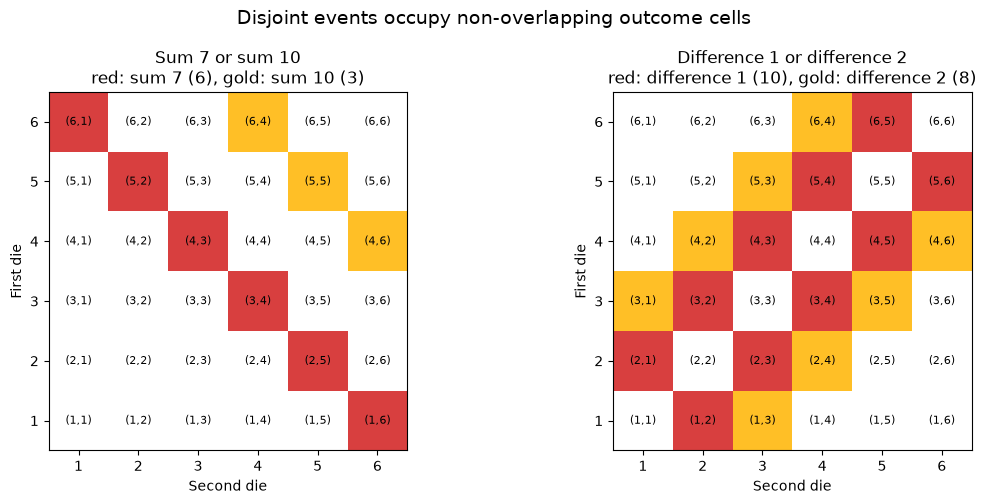

In [4]:
sum_event_grid: np.ndarray = np.ones((6, 6, 3))
difference_event_grid: np.ndarray = np.ones((6, 6, 3))
sum_seven_color: np.ndarray = np.array([0.85, 0.25, 0.25])
sum_ten_color: np.ndarray = np.array([1.0, 0.75, 0.15])
difference_one_color: np.ndarray = np.array([0.85, 0.25, 0.25])
difference_two_color: np.ndarray = np.array([1.0, 0.75, 0.15])

for first_die in range(1, 7):
    for second_die in range(1, 7):
        if first_die + second_die == 7:
            sum_event_grid[first_die - 1, second_die - 1] = sum_seven_color
        elif first_die + second_die == 10:
            sum_event_grid[first_die - 1, second_die - 1] = sum_ten_color

        absolute_difference: int = abs(first_die - second_die)
        if absolute_difference == 1:
            difference_event_grid[first_die - 1, second_die - 1] = difference_one_color
        elif absolute_difference == 2:
            difference_event_grid[first_die - 1, second_die - 1] = difference_two_color

fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.1))
grid_specs = [
    (sum_event_grid, "Sum 7 or sum 10", "red: sum 7 (6), gold: sum 10 (3)"),
    (difference_event_grid, "Difference 1 or difference 2",
     "red: difference 1 (10), gold: difference 2 (8)"),
]

for ax, (event_grid, title, subtitle) in zip(axes, grid_specs, strict=True):
    ax.imshow(event_grid, origin="lower")
    for first_die in range(1, 7):
        for second_die in range(1, 7):
            ax.text(second_die - 1, first_die - 1, f"({first_die},{second_die})",
                    ha="center", va="center", fontsize=8)
    ax.set(
        title=f"{title}\n{subtitle}",
        xlabel="Second die",
        ylabel="First die",
        xticks=np.arange(6),
        yticks=np.arange(6),
        xticklabels=np.arange(1, 7),
        yticklabels=np.arange(1, 7),
    )

fig.suptitle("Disjoint events occupy non-overlapping outcome cells", fontsize=14)
fig.tight_layout()
plt.show()

### Why disjointness matters

If events overlap, simply adding $P(A)$ and $P(B)$ counts the shared outcomes twice. The general addition rule corrects this:

$$
P(A\cup B)=P(A)+P(B)-P(A\cap B).
$$

For disjoint events, $P(A\cap B)=0$, so the formula reduces to

$$
P(A\cup B)=P(A)+P(B).
$$

Thus, check for overlap before adding probabilities.

### Takeaway

For disjoint events,

$$
\boxed{P(A\cup B)=P(A)+P(B).}
$$

| Event union | Why disjoint? | Probability |
|---|---|---:|
| Soccer or basketball | Each child plays at most one sport | $0.7$ |
| Even die result or five | Five is not even | $\frac23$ |
| Two-dice sum $7$ or sum $10$ | One pair has only one sum | $\frac14$ |
| Absolute difference $1$ or $2$ | One pair has only one difference | $\frac12$ |

The rule works because the event outcome counts can be combined without double-counting.

## Video 6 — Adding probabilities of overlapping events

When events overlap, simply adding their probabilities counts the shared outcomes twice.

The **intersection** $A\cap B$ is the event that both $A$ and $B$ occur. The addition rule for any two events is

$$
\boxed{
P(A\cup B)
=
P(A)+P(B)-P(A\cap B).
}
$$

This is the two-event **inclusion-exclusion principle**:

1. include all outcomes in $A$;
2. include all outcomes in $B$;
3. exclude one copy of the intersection that was included twice.

### Rain or wind: the overlap is required

Suppose

$$
P(\text{rain})=0.8
\qquad\text{and}\qquad
P(\text{wind})=0.7.
$$

Adding them directly gives $1.5$, which cannot be a probability. Rain and wind can occur together, so their overlap has been counted twice.

The correct expression is

$$
P(\text{rain or wind})
=
0.8+0.7-P(\text{rain and wind}).
$$

Without the intersection probability, the exact probability of rain or wind cannot be determined from the two individual probabilities alone.

### School example with overlapping sports

A school has ten children:

- $6$ play soccer;
- $5$ play basketball;
- $3$ play both sports.

Adding $6+5$ counts each of the three children in both sports twice. Subtract one copy of that overlap:

$$
\begin{aligned}
|S\cup B|
&=|S|+|B|-|S\cap B| \\
&=6+5-3 \\
&=8.
\end{aligned}
$$

Thus, eight children play soccer, basketball, or both. The remaining two play neither sport.

### The same calculation with probabilities

Divide the event counts by the ten children:

$$
P(S)=0.6,
\qquad
P(B)=0.5,
\qquad
P(S\cap B)=0.3.
$$

Apply inclusion-exclusion:

$$
\begin{aligned}
P(S\cup B)
&=P(S)+P(B)-P(S\cap B) \\
&=0.6+0.5-0.3 \\
&=\boxed{0.8}.
\end{aligned}
$$

Here “soccer or basketball” uses the inclusive mathematical meaning of **or**: soccer, basketball, or both.

### Disjoint events are a special case

For disjoint events,

$$
A\cap B=\varnothing
$$

and therefore

$$
P(A\cap B)=0.
$$

The general rule becomes

$$
P(A\cup B)=P(A)+P(B)-0=P(A)+P(B).
$$

Thus, the disjoint addition rule is not a separate principle; it is the zero-overlap case of inclusion-exclusion.

> The course also calls overlapping events “joint” or “non-mutually exclusive.” Here, **overlapping events** is the clearest term; their intersection is the joint event in which both occur.

### Two dice: sum seven or difference one

Roll two fair dice and define

- $A$: the sum is $7$;
- $B$: the absolute difference is $1$.

There are $36$ equally likely ordered pairs. The event counts are

$$
|A|=6
\qquad\text{and}\qquad
|B|=10.
$$

Two outcomes satisfy both conditions:

$$
A\cap B=\{(3,4),(4,3)\}.
$$

Therefore,

$$
\begin{aligned}
P(A\cup B)
&=\frac6{36}+\frac{10}{36}-\frac2{36} \\
&=\frac{14}{36} \\
&=\boxed{\frac7{18}}.
\end{aligned}
$$

### Seeing the overlap

The first diagram shows the three children counted in both sport groups. The dice grid colors outcomes belonging only to $A$, only to $B$, and to their intersection.

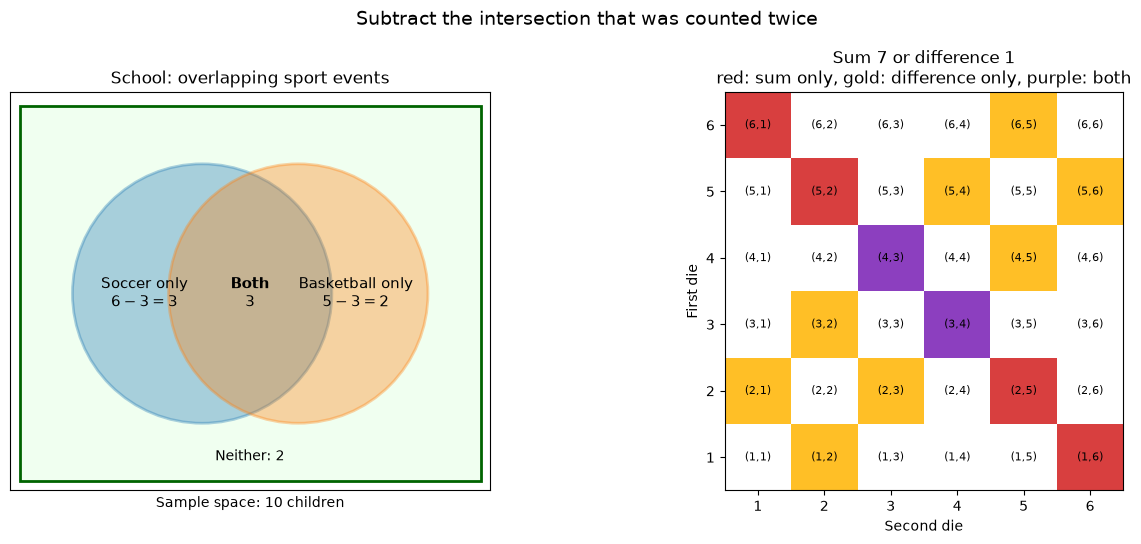

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.5))

school_sample_space = Rectangle((0.2, 0.2), 9.6, 7.8, facecolor="honeydew",
                                edgecolor="darkgreen", linewidth=2)
soccer_circle = Circle((4.0, 4.1), 2.7, facecolor="tab:blue", edgecolor="tab:blue",
                       alpha=0.35, linewidth=2)
basketball_circle = Circle((6.0, 4.1), 2.7, facecolor="tab:orange",
                           edgecolor="tab:orange", alpha=0.35, linewidth=2)
axes[0].add_patch(school_sample_space)
axes[0].add_patch(soccer_circle)
axes[0].add_patch(basketball_circle)
axes[0].text(2.8, 4.1, "Soccer only\n$6-3=3$", ha="center", va="center", fontsize=11)
axes[0].text(5.0, 4.1, "Both\n$3$", ha="center", va="center", fontsize=11,
             fontweight="bold")
axes[0].text(7.2, 4.1, "Basketball only\n$5-3=2$", ha="center", va="center", fontsize=11)
axes[0].text(5.0, 0.7, "Neither: $2$", ha="center", va="center", fontsize=10)
axes[0].set(title="School: overlapping sport events", xlim=(0, 10), ylim=(0, 8.3),
            xticks=[], yticks=[], xlabel="Sample space: 10 children", ylabel="")
axes[0].set_aspect("equal")

dice_overlap_grid: np.ndarray = np.ones((6, 6, 3))
sum_only_color: np.ndarray = np.array([0.85, 0.25, 0.25])
difference_only_color: np.ndarray = np.array([1.0, 0.75, 0.15])
intersection_color: np.ndarray = np.array([0.55, 0.25, 0.75])

for first_die in range(1, 7):
    for second_die in range(1, 7):
        belongs_to_sum: bool = first_die + second_die == 7
        belongs_to_difference: bool = abs(first_die - second_die) == 1
        if belongs_to_sum and belongs_to_difference:
            dice_overlap_grid[first_die - 1, second_die - 1] = intersection_color
        elif belongs_to_sum:
            dice_overlap_grid[first_die - 1, second_die - 1] = sum_only_color
        elif belongs_to_difference:
            dice_overlap_grid[first_die - 1, second_die - 1] = difference_only_color

axes[1].imshow(dice_overlap_grid, origin="lower")
for first_die in range(1, 7):
    for second_die in range(1, 7):
        axes[1].text(second_die - 1, first_die - 1, f"({first_die},{second_die})",
                     ha="center", va="center", fontsize=8)
axes[1].set(
    title="Sum 7 or difference 1\nred: sum only, gold: difference only, purple: both",
    xlabel="Second die",
    ylabel="First die",
    xticks=np.arange(6),
    yticks=np.arange(6),
    xticklabels=np.arange(1, 7),
    yticklabels=np.arange(1, 7),
)

fig.suptitle("Subtract the intersection that was counted twice", fontsize=14)
fig.tight_layout()
plt.show()

### Takeaway

For any two events,

$$
\boxed{P(A\cup B)=P(A)+P(B)-P(A\cap B).}
$$

| Situation | Intersection | Union calculation |
|---|---:|---:|
| Soccer or basketball | $0.3$ | $0.6+0.5-0.3=0.8$ |
| Sum $7$ or difference $1$ | $\frac2{36}$ | $\frac6{36}+\frac{10}{36}-\frac2{36}=\frac7{18}$ |
| Disjoint events | $0$ | $P(A)+P(B)$ |

Subtracting the intersection removes exactly one of its two copies and prevents double-counting.

## Video 7 — Independence and the multiplication rule

Events $A$ and $B$ are **independent** when learning that one occurred does not change the probability of the other.

Examples include separate tosses of a fair coin: the first result does not affect the physical probabilities on the next toss. By contrast, consecutive chess positions are dependent because one move changes which later moves are possible.

For independent events, the probability that both occur is

$$
\boxed{P(A\cap B)=P(A)P(B).}
$$

This is the probability multiplication rule for independent events. The independence condition is essential.

### Randomly splitting a school into equal rooms

A school has $100$ children:

- $50$ like soccer;
- $50$ do not like soccer.

The children are randomly assigned to two rooms of $50$. Because room assignment does not use soccer preference, the best estimate for the number of soccer-preferring children in each room is

$$
50(0.5)=25.
$$

An actual random split need not contain exactly $25$ in each room. The value $25$ is the expected count around which random splits vary.

### Unequal room sizes

Now suppose:

- $40$ of $100$ children like soccer, so $P(S)=0.4$;
- room 1 contains $30$ children, so a randomly selected child has $P(R_1)=0.3$ of being assigned there;
- room 2 contains the other $70$ children.

Random assignment makes soccer preference independent of room assignment. Therefore,

$$
\begin{aligned}
P(S\cap R_1)
&=P(S)P(R_1) \\
&=0.4(0.3) \\
&=0.12.
\end{aligned}
$$

Thus, the expected number of children who both like soccer and are in room 1 is

$$
100(0.12)=12.
$$

Equivalently, the expected soccer proportion in room 1 is $40\%$, and $40\%$ of $30$ is $12$.

### Expected does not mean guaranteed

A random room of $30$ children may contain fewer or more than $12$ soccer-preferring children. Repeating the random split many times produces a distribution of possible counts centered near $12$.

The following deterministic simulation uses a fixed seed and $10{,}000$ synthetic random splits. The second plot shows how the probability of repeated identical outcomes decreases as more independent trials are required.

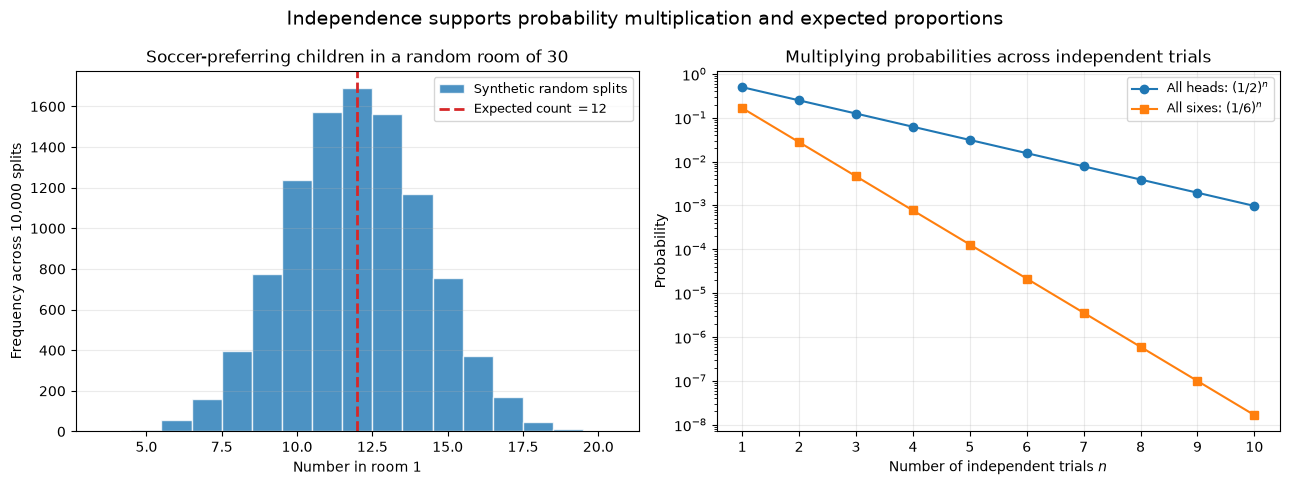

In [6]:
independence_rng: np.random.Generator = np.random.default_rng(123)
random_split_count: int = 10_000
soccer_counts_room_one: np.ndarray = independence_rng.hypergeometric(
    ngood=40, nbad=60, nsample=30, size=random_split_count
)
expected_soccer_count: float = 30.0 * 0.4
independent_trial_counts: np.ndarray = np.arange(1, 11)
all_heads_probabilities: np.ndarray = (1.0 / 2.0) ** independent_trial_counts
all_sixes_probabilities: np.ndarray = (1.0 / 6.0) ** independent_trial_counts

fig, axes = plt.subplots(1, 2, figsize=(13, 4.9))
axes[0].hist(soccer_counts_room_one, bins=np.arange(3.5, 21.5, 1), color="tab:blue",
             edgecolor="white", alpha=0.8, label="Synthetic random splits")
axes[0].axvline(expected_soccer_count, color="tab:red", linestyle="--", linewidth=2,
                label="Expected count $=12$")
axes[0].set(title="Soccer-preferring children in a random room of 30",
            xlabel="Number in room 1", ylabel="Frequency across 10,000 splits")
axes[0].grid(axis="y", alpha=0.25)
axes[0].legend(fontsize=9)

axes[1].semilogy(independent_trial_counts, all_heads_probabilities, marker="o",
                 color="tab:blue", label="All heads: $(1/2)^n$")
axes[1].semilogy(independent_trial_counts, all_sixes_probabilities, marker="s",
                 color="tab:orange", label="All sixes: $(1/6)^n$")
axes[1].set(title="Multiplying probabilities across independent trials",
            xlabel="Number of independent trials $n$", ylabel="Probability",
            xticks=independent_trial_counts)
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=9)

fig.suptitle(
    "Independence supports probability multiplication and expected proportions",
    fontsize=14,
)
fig.tight_layout()
plt.show()

### Five independent coin tosses

For a fair coin,

$$
P(H)=\frac12.
$$

The five tosses are mutually independent, so the probability of five heads is

$$
\begin{aligned}
P(HHHHH)
&=\frac12\cdot\frac12\cdot\frac12\cdot\frac12\cdot\frac12 \\
&=\left(\frac12\right)^5 \\
&=\boxed{\frac1{32}}.
\end{aligned}
$$

### Independent dice rolls

For one fair die,

$$
P(6)=\frac16.
$$

Two independent dice both showing six has probability

$$
P(6,6)=\frac16\cdot\frac16=\boxed{\frac1{36}}.
$$

For ten independent fair dice, the probability that every die shows six is

$$
P(\text{ten sixes})
=
\left(\frac16\right)^{10}
=
\frac1{60{,}466{,}176}
\approx1.65\times10^{-8}.
$$

Requiring more independent events to occur together rapidly makes the joint event less likely.

### Extending the rule

For mutually independent events $A_1,A_2,\ldots,A_n$,

$$
\boxed{
P(A_1\cap A_2\cap\cdots\cap A_n)
=
\prod_{i=1}^{n}P(A_i).
}
$$

“Mutually independent” means the needed independence relationships hold for every collection of these events, not only for individual pairs.

Without independence, the simple product $P(A)P(B)$ generally does not equal $P(A\cap B)$. Later, conditional probability will provide the more general multiplication rule.

### Takeaway

Independence means that one event does not change the probability of another. For independent events,

$$
\boxed{P(A\cap B)=P(A)P(B).}
$$

| Independent event combination | Probability |
|---|---:|
| Likes soccer and assigned to room 1 | $0.4(0.3)=0.12$ |
| Five fair tosses are all heads | $(\frac12)^5=\frac1{32}$ |
| Two fair dice are both six | $(\frac16)^2=\frac1{36}$ |
| Ten fair dice are all six | $(\frac16)^{10}$ |

The multiplication is justified by independence; it is not a rule that can be applied to arbitrary events.

## Video 8 — The birthday problem

The birthday problem asks:

> In a group of $n$ people, what is the probability that at least two people share a birthday?

Use the simplified model from the lecture:

- the year has $365$ possible birthdays;
- February 29 is ignored;
- each birthday is equally likely;
- different people's birthdays are independent.

These assumptions make the calculation tractable. Real birthday frequencies are not perfectly uniform, so the result is a model rather than an exact description of every population.

### Use the complement

Directly counting every possible way that at least one birthday match can occur is difficult. It is easier to calculate the complement:

$$
A=\{\text{at least two people share a birthday}\},
$$

$$
A^c=\{\text{all birthdays are different}\}.
$$

The complement rule gives

$$
\boxed{
P(A)=1-P(A^c).
}
$$

So the main task is to calculate the probability that all $n$ birthdays are different.

### Build the no-match probability one person at a time

For the first person, any birthday is allowed:

$$
\frac{365}{365}=1.
$$

For the second person to avoid a match, $364$ of the $365$ days remain:

$$
\frac{364}{365}.
$$

Provided the first two birthdays differ, the third person has $363$ available days:

$$
\frac{363}{365}.
$$

Continuing this reasoning, the probability that the first $n$ people all have different birthdays is

$$
\boxed{
P(\text{all different})
=
1\cdot\frac{364}{365}\cdot\frac{363}{365}\cdots
\frac{365-(n-1)}{365}.
}
$$

The birthdays themselves are modeled as independent, but the events “person $k$ avoids every previous birthday” depend on what happened earlier. This sequential product will later be formalized using conditional probability.

### General formula

For $0\le n\le365$,

$$
P(\text{all different})
=
\prod_{k=0}^{n-1}\frac{365-k}{365}
=
\frac{365!}{(365-n)!\,365^n}.
$$

Therefore,

$$
\boxed{
P(\text{at least one shared birthday})
=
1-
\prod_{k=0}^{n-1}\frac{365-k}{365}.
}
$$

For $n>365$, the probability of all different birthdays is $0$: with more people than available days, at least one birthday must repeat.

### Selected group sizes

The no-shared-birthday probability decreases quickly:

| People $n$ | $P(\text{all different})$ | $P(\text{at least one match})$ |
|---:|---:|---:|
| $2$ | $0.9973$ | $0.0027$ |
| $9$ | $0.9054$ | $0.0946$ |
| $20$ | $0.5886$ | $0.4114$ |
| $23$ | $0.4927$ | $0.5073$ |
| $30$ | $0.2937$ | $0.7063$ |
| $50$ | $0.0296$ | $0.9704$ |
| $100$ | approximately $3.07\times10^{-7}$ | approximately $0.9999997$ |

At $23$ people, a shared birthday is already more likely than no shared birthday. For $30$ people, the match probability is about $70.6\%$.

### Plotting the two complementary probabilities

The following computation evaluates the sequential product directly. The curves add to $1$ at every group size because they represent complementary events.

 people | all different | at least one match
--------+---------------+-------------------
      2 |     0.9972603 |         0.0027397
      9 |     0.9053762 |         0.0946238
     20 |     0.5885616 |         0.4114384
     23 |     0.4927028 |         0.5072972
     30 |     0.2936838 |         0.7063162
     50 |     0.0296264 |         0.9703736
    100 |     0.0000003 |         0.9999997
    366 |     0.0000000 |         1.0000000


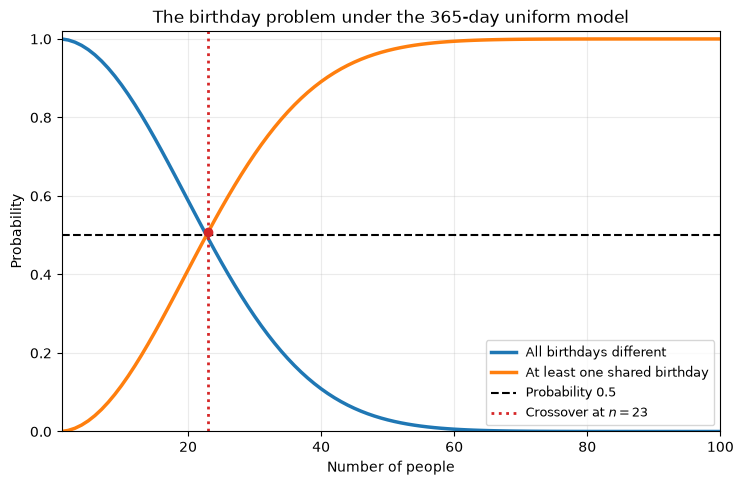

In [7]:
def probability_all_birthdays_different(group_size: int, days: int = 365) -> float:
    """Return the probability that all birthdays differ under the uniform model."""
    if group_size < 0:
        raise ValueError("group_size must be nonnegative")
    if group_size > days:
        return 0.0

    probability: float = 1.0
    for person_index in range(group_size):
        probability *= (days - person_index) / days
    return probability


birthday_group_sizes: np.ndarray = np.arange(1, 101)
no_match_probabilities: np.ndarray = np.array(
    [probability_all_birthdays_different(int(size)) for size in birthday_group_sizes]
)
match_probabilities: np.ndarray = 1.0 - no_match_probabilities
birthday_selected_sizes: list[int] = [2, 9, 20, 23, 30, 50, 100, 366]

print(" people | all different | at least one match")
print("--------+---------------+-------------------")
for group_size in birthday_selected_sizes:
    no_match_probability: float = probability_all_birthdays_different(group_size)
    match_probability: float = 1.0 - no_match_probability
    print(f"{group_size:7d} | {no_match_probability:13.7f} | {match_probability:17.7f}")

fig, ax = plt.subplots(figsize=(8.5, 5.2))
ax.plot(birthday_group_sizes, no_match_probabilities, color="tab:blue", linewidth=2.5,
        label="All birthdays different")
ax.plot(birthday_group_sizes, match_probabilities, color="tab:orange", linewidth=2.5,
        label="At least one shared birthday")
ax.axhline(0.5, color="black", linestyle="--", linewidth=1.5, label="Probability $0.5$")
ax.axvline(23, color="tab:red", linestyle=":", linewidth=2, label="Crossover at $n=23$")
ax.scatter([23], [1.0 - probability_all_birthdays_different(23)], color="tab:red", zorder=4)
ax.set(
    title="The birthday problem under the 365-day uniform model",
    xlabel="Number of people",
    ylabel="Probability",
    xlim=(1, 100),
    ylim=(0, 1.02),
)
ax.grid(alpha=0.25)
ax.legend(fontsize=9)
plt.show()

### Why the result is surprising

With $23$ people, there are not merely $23$ opportunities for a match. Every pair of people can be compared.

The number of distinct pairs is

$$
\binom{23}{2}
=
\frac{23\cdot22}{2}
=253.
$$

Those many pairwise comparison opportunities make a collision plausible even though each individual has $365$ possible birthdays.

This pair-count explanation provides intuition, while the complement calculation gives the exact probability under the model.

### Takeaway

The birthday problem is easiest through the complement:

$$
\boxed{
P(\text{at least one match})
=
1-P(\text{all different}).
}
$$

For $n\le365$,

$$
P(\text{all different})
=
\prod_{k=0}^{n-1}\frac{365-k}{365}.
$$

The probability of a shared birthday exceeds $0.5$ at only $23$ people and is about $0.706$ for $30$ people. This example combines sample spaces, complements, and sequential probability multiplication.